<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/plots_and_code_for_analytics_modeule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3554 non-null   object 
 1   society          3554 non-null   object 
 2   sector           3554 non-null   object 
 3   price            3554 non-null   float64
 4   price_per_sqft   3554 non-null   float64
 5   bedRoom          3554 non-null   float64
 6   bathroom         3554 non-null   float64
 7   balcony          3554 non-null   object 
 8   floorNum         3554 non-null   float64
 9   agePossession    3554 non-null   object 
 10  built_up_area    3554 non-null   float64
 11  study room       3554 non-null   float64
 12  servant room     3554 non-null   float64
 13  store room       3554 non-null   float64
 14  pooja room       3554 non-null   float64
 15  others           3554 non-null   float64
 16  furnishing_type  3554 non-null   float64
 17  luxury_score  

# Coordinate scraper

In [ ]:
import pandas as pd
import requests
import time

def get_coordinates_osm(location):
    url = "https://nominatim.openstreetmap.org/search"
    params = {
        'q': location,
        'format': 'json',
        'limit': 1
    }
    headers = {
        'User-Agent': 'Mozilla/5.0'
    }
    response = requests.get(url, params=params, headers=headers)

    if response.status_code == 200:
        data = response.json()
        if data:
            lat = data[0]['lat']
            lon = data[0]['lon']
            return f"{lat}, {lon}"
    return None

# Loop over all sectors
data = []

for sector in range(1, 116):
    query = f"Sector {sector}, Gurgaon, India"
    print(f"Getting coordinates for {query}")
    coords = get_coordinates_osm(query)
    data.append({"sector": f"Sector {sector}", "coordinates": coords})
    time.sleep(1.5)

# Save results
df = pd.DataFrame(data)
df.to_csv("latlong.csv", index=False)


Getting coordinates for Sector 1, Gurgaon, India
Getting coordinates for Sector 2, Gurgaon, India
Getting coordinates for Sector 3, Gurgaon, India
Getting coordinates for Sector 4, Gurgaon, India
Getting coordinates for Sector 5, Gurgaon, India
Getting coordinates for Sector 6, Gurgaon, India
Getting coordinates for Sector 7, Gurgaon, India
Getting coordinates for Sector 8, Gurgaon, India
Getting coordinates for Sector 9, Gurgaon, India
Getting coordinates for Sector 10, Gurgaon, India
Getting coordinates for Sector 11, Gurgaon, India
Getting coordinates for Sector 12, Gurgaon, India
Getting coordinates for Sector 13, Gurgaon, India
Getting coordinates for Sector 14, Gurgaon, India
Getting coordinates for Sector 15, Gurgaon, India
Getting coordinates for Sector 16, Gurgaon, India
Getting coordinates for Sector 17, Gurgaon, India
Getting coordinates for Sector 18, Gurgaon, India
Getting coordinates for Sector 19, Gurgaon, India
Getting coordinates for Sector 20, Gurgaon, India
Getting c

In [6]:
latlong = pd.read_csv('/content/latlong.csv')

In [7]:
latlong.head()

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"


In [ ]:
# extract latitde and longitude from coordinates

In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [9]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [10]:
new_df = df.merge(latlong,on='sector')

In [11]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,"28.4160° N, 76.9914° E",28.4160,76.9914
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,...,1.0,1.0,0.0,0.0,0.0,0.0,38.0,"28.4253° N, 76.9439° E",28.4253,76.9439
2,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,...,0.0,1.0,0.0,0.0,1.0,1.0,174.0,"28.4079° N, 76.9153° E",28.4079,76.9153
3,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,...,0.0,0.0,1.0,0.0,0.0,0.0,159.0,"28.4750° N, 76.9715° E",28.4750,76.9715
4,flat,paras quartier,gwal pahari,7.50,14019.0,4.0,4.0,3+,20.0,New Property,...,0.0,1.0,0.0,1.0,1.0,1.0,49.0,"28.4484° N, 77.0210° E",28.4484,77.0210


In [12]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3329 entries, 0 to 3328
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3329 non-null   object 
 1   society          3329 non-null   object 
 2   sector           3329 non-null   object 
 3   price            3329 non-null   float64
 4   price_per_sqft   3329 non-null   float64
 5   bedRoom          3329 non-null   float64
 6   bathroom         3329 non-null   float64
 7   balcony          3329 non-null   object 
 8   floorNum         3329 non-null   float64
 9   agePossession    3329 non-null   object 
 10  built_up_area    3329 non-null   float64
 11  study room       3329 non-null   float64
 12  servant room     3329 non-null   float64
 13  store room       3329 non-null   float64
 14  pooja room       3329 non-null   float64
 15  others           3329 non-null   float64
 16  furnishing_type  3329 non-null   float64
 17  luxury_score  

In [13]:
new_df=new_df.drop(columns=['property_type','society','bedRoom','bathroom','balcony','floorNum','agePossession','study room','servant room','store room','pooja room','others','furnishing_type','luxury_score','coordinates'])

In [14]:
new_df.head()

,sector,price,price_per_sqft,built_up_area,latitude,longitude
0,sector 36,0.82,7586.0,850.0,28.4160,76.9914
1,sector 89,0.95,8597.0,1226.0,28.4253,76.9439
2,sector 92,1.60,8020.0,1615.0,28.4079,76.9153
3,sector 102,0.48,9023.0,582.0,28.4750,76.9715
4,gwal pahari,7.50,14019.0,4842.0,28.4484,77.0210


In [15]:
group_df = new_df.groupby('sector').mean()[['price','price_per_sqft','built_up_area','latitude','longitude']]

In [16]:
group_df.head()

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715


In [17]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [ ]:
# export the data frame to plot on streamlit

new_df.to_csv('data_viz1.csv',index=False)

# Word Cloud of the amenities

In [19]:
df1 = pd.read_csv('/content/gurgaon_properties.csv')

In [20]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,4 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,not available,"002, Sector 69 Gurgaon, Gurgaon, Haryana",0.0,South-East,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",Ground floor with extended balcony this 4 bhk ...,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...","['Water purifier', 'Security / Fire Alarm', 'P...","['Green Area5 out of 5', 'Construction4 out of..."
1,9 Bedroom House for sale in Sector 40 Gurgaon,house,independent,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,"servant room,store room","7777, Sector 40 Gurgaon, Gurgaon, Haryana",3.0,North-West,5 to 10 Year Old,"['Huda city centre metro station', 'Axis bank ...",Its wonderfully made 3bhk on each floor with b...,"['10 Wardrobe', '21 Fan', '1 Exhaust Fan', '9 ...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
2,3 BHK Flat in Sector 102 Gurgaon,flat,bptp amstoria,1.90,8444.0,2250.0,Super Built up area 2727(253.35 sq.m.)Built Up...,3,3,3+,servant room,"1021, Sector 102 Gurgaon, Gurgaon, Haryana",1.0,North-East,1 to 5 Year Old,"['Early Basket Grocery shop', 'Conscient One M...",This beautiful 3 bhk flat in sector 102 gurgao...,"['5 Fan', '2 Geyser', '5 Light', '4 AC', '1 Mo...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area4 out of 5', 'Construction4.5 out ..."
3,3 BHK Flat in Sector-33 Sohna,flat,central park flower valley,1.40,21538.0,650.0,Super Built up area 650(60.39 sq.m.),3,3,3,not available,"Sector-33 Sohna, Gurgaon, Haryana",2.0,NaN,By 2023,"['Golf Course Extension Rd', 'Rajiv Chowk - So...","Well maintained, 24 hours security. Playing gr...",[],"['Lift(s)', 'Swimming Pool', 'Park', 'Visitor ...",NaN
4,2 Bedroom House for sale in Sector 9 Gurgaon,house,independent,1.65,18333.0,900.0,Built Up area: 900 (83.61 sq.m.),2,3,0,not available,"Sector 9, Sector 9 Gurgaon, Gurgaon, Haryana",3.0,NaN,undefined,NaN,2bhk residential house for resale in sector 9 ...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [21]:
word_cloud_df = df1.merge(df,left_index=True , right_index=True)[['features','sector']]

In [22]:
word_cloud_df

,features,sector
0,"['Water purifier', 'Security / Fire Alarm', 'P...",sector 36
1,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 89
2,"['Centrally Air Conditioned', 'Water purifier'...",sohna road
3,"['Lift(s)', 'Swimming Pool', 'Park', 'Visitor ...",sector 92
4,NaN,sector 102
...,...,...
3549,"['Private Garden / Terrace', 'Water Storage', ...",sector 84
3550,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 109
3551,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 2
3552,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 43


In [23]:
sector_amenities = word_cloud_df.groupby("sector")['features'].apply(lambda x:' '.join(x.astype(str))).reset_index()

In [24]:
sector_amenities.head()

,sector,features
0,dwarka expressway,"['Feng Shui / Vaastu Compliant', 'Security / F..."
1,gwal pahari,"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
2,manesar,"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
3,sector 1,"nan ['Lift(s)', 'Maintenance Staff', 'Swimming..."
4,sector 10,"nan ['Security / Fire Alarm', 'Feng Shui / Vaa..."


In [36]:
sector_amenities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sector    104 non-null    object
 1   features  104 non-null    object
dtypes: object(2)
memory usage: 1.8+ KB


In [ ]:
# each feature is a string in list which is in a string

In [37]:
from wordcloud import WordCloud,STOPWORDS

In [ ]:
# code make a snigle string using ast

In [ ]:
# make wordcloud

 # scatter plot of area vs price

In [38]:
df = pd.read_csv('/content/gurgaon_properties_post_feature_selection_v2.csv')

In [39]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,0.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,1.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,0.0,High,Mid Floor


In [49]:
fig = px.scatter(df,x="built_up_area",y="price",color="bedRoom",title ="area vs price")

In [51]:
fig.show()

In [54]:
piechart = px.pie(df,names='bedRoom',title='bhk')
piechart.show()

In [61]:
sector_options = df['sector'].tolist()

In [62]:
type(sector_options)

list

In [64]:
df['bedRoom'].value_counts()

,count
bedRoom,
3.0,1512
2.0,969
4.0,647
5.0,171
1.0,127
6.0,53
9.0,25
7.0,20
8.0,18


In [69]:
temp_df = df[df['bedRoom']<=4]

In [70]:
boxplot = px.box(temp_df , x='bedRoom' , y='price')
boxplot.show()

<Axes: xlabel='price', ylabel='Density'>

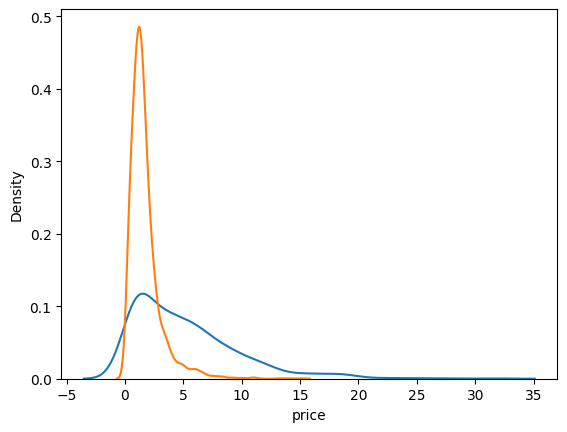